# Tasks 2 & 3: Model Explainability and Business Recommendations

**Objective**: Evaluate and interpret the pre-trained fraud detection models for both E-commerce and Credit Card transactions using performance metrics and SHAP analysis. Provide actionable business recommendations based on the findings.

## 1. Setup and Configurations

In [12]:
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap
import joblib
from pathlib import Path

# Add src to path for modular imports
sys.path.append('../')

from src.visualisation import plotter as plotter_module
from src.pipeline import tabular_modeling as tm

# Configuration
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:.4f}".format

ROOT = Path("..").resolve()
FIGURES_DIR = ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Initialize Plotter
plotter = plotter_module.Plotter(figures_dir=FIGURES_DIR)

---

## 2. E-commerce Fraud Model Analysis

### 2.1 Load Data and Model

In [13]:
FRAUD_DATA_PATH = ROOT / "data" / "processed" / "Fraud_Data_Processed.csv"
FRAUD_MODEL_PATH = ROOT / "models" / "fraud.pkl"

# Load Data
fraud_df = pd.read_csv(FRAUD_DATA_PATH)
print(f"E-commerce Data Shape: {fraud_df.shape}")
print(fraud_df.head())

# Pre-split separation (replicating training logic to get test set)
TARGET_COL = "class"
DROP_COLS = ["signup_time", "purchase_time"]

X_train, X_test, y_train, y_test = tm.split_features_target(
    fraud_df, target=TARGET_COL, drop_cols=DROP_COLS, stratify=True, test_size=0.2, random_state=42
)

# Load Model
try:
    fraud_pipeline = joblib.load(FRAUD_MODEL_PATH)
    print("E-commerce Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    raise e

E-commerce Data Shape: (151112, 19)
   user_id          signup_time        purchase_time  purchase_value  \
0    62421  2015-02-16 00:17:05  2015-03-08 10:00:39              46   
1   173212  2015-03-08 04:03:22  2015-03-20 17:23:45              33   
2   242286  2015-05-17 16:45:54  2015-05-26 08:54:34              33   
3   370003  2015-03-03 19:58:39  2015-05-28 21:09:13              33   
4   119824  2015-03-20 00:31:27  2015-04-05 07:31:46              55   

       device_id  source  browser sex  age  ip_address  class country  \
0  ZCLZTAJPCRAQX  Direct   Safari   M   36  52093.4969      0     NaN   
1  YFGYOALADBHLT     Ads       IE   F   30  93447.1390      0     NaN   
2  QZNVQTUITFTHH  Direct  FireFox   F   32 105818.5015      0     NaN   
3  PIBUQMBIELMMG     Ads       IE   M   40 117566.6649      0     NaN   
4  WFIIFCPIOGMHT     Ads   Safari   M   38 131423.7890      0     NaN   

   time_since_signup  hour_of_day  day_of_week  purchase_month  \
0       1763014.0000      

### 2.2 Performance Evaluation

Performance Metrics:


,model,accuracy,precision,recall,f1,roc_auc
0,E-commerce Model,0.9144,0.5328,0.6993,0.6048,0.8383


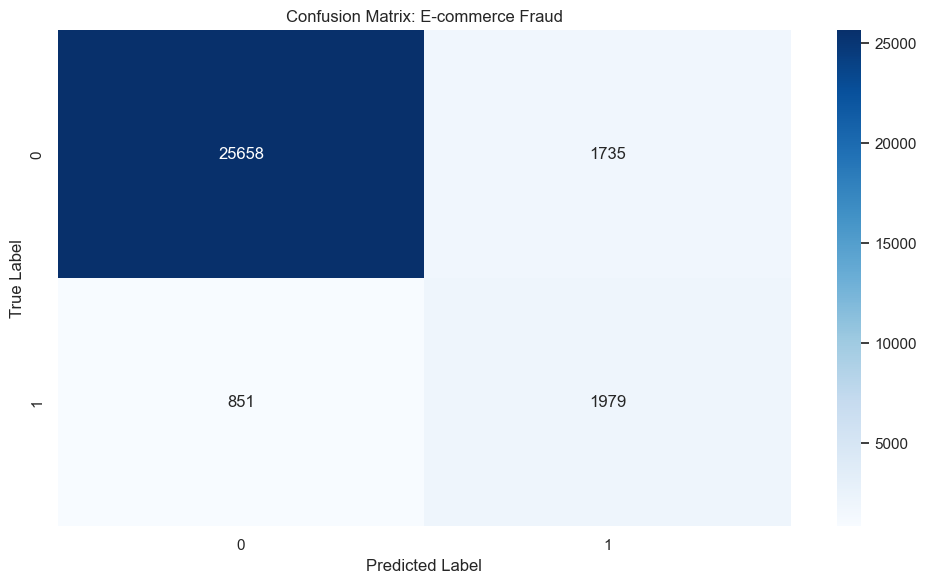

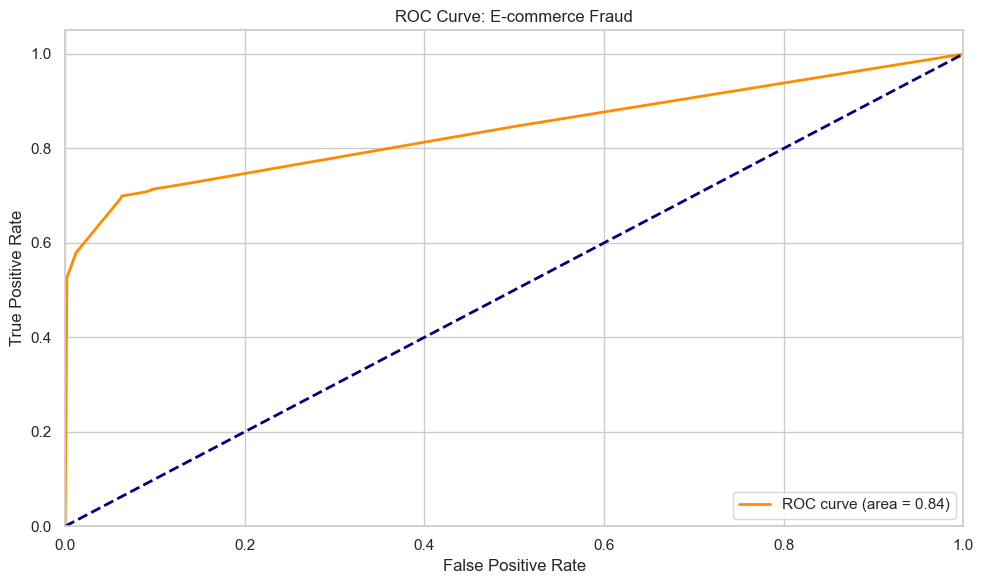

In [14]:
print("Performance Metrics:")
metrics = tm.evaluate_classification({"E-commerce Model": fraud_pipeline}, X_test, y_test)
display(metrics)

y_pred = fraud_pipeline.predict(X_test)
y_proba = fraud_pipeline.predict_proba(X_test)[:, 1]

plotter.plot_confusion_matrix(y_test, y_pred, title="Confusion Matrix: E-commerce Fraud")
plotter.plot_roc_curve(y_test, y_proba, title="ROC Curve: E-commerce Fraud")

### 2.3 Feature Importance (Built-in)
We visualize the top 10 most important features according to the model's internal gain/gini calculation.

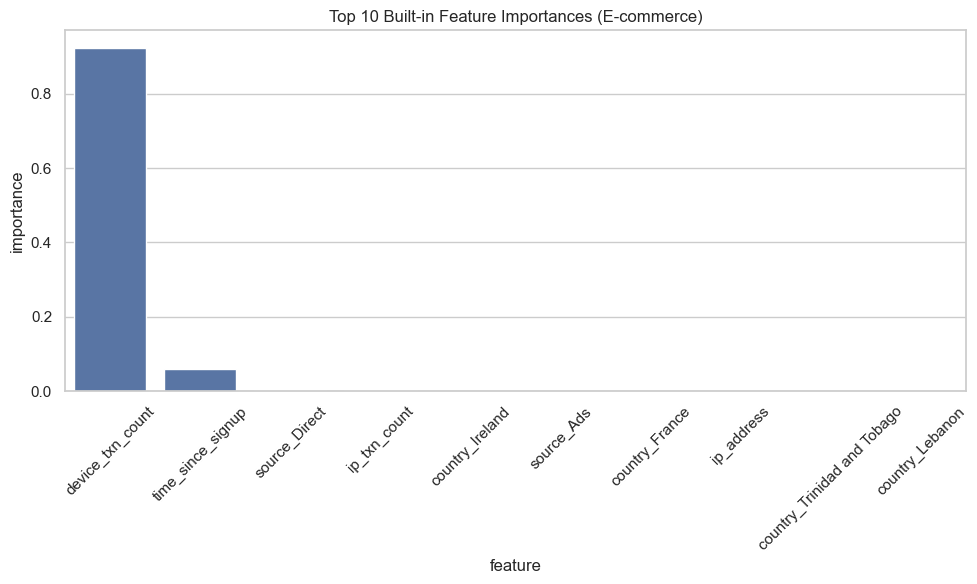

In [15]:
classifier = fraud_pipeline.named_steps['model']
prep = fraud_pipeline.named_steps['prep']

if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    # Recover feature names after preprocessing
    num_cols = list(prep.named_transformers_['num'].get_feature_names_out())
    # Handle categorical names (usually cat__source_Ads etc)
    # Note: tabular_modeling uses ('cat', Pipeline(steps=[(..., encoder)]), list(cols))
    cat_pipeline = prep.named_transformers_['cat']
    ohe = cat_pipeline.named_steps['encoder']
    cat_orig_cols = prep.transformers_[1][2] # list of categorical columns passed
    ohe_cols = list(ohe.get_feature_names_out(cat_orig_cols))
    feature_names = num_cols + ohe_cols
    
    feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(10)
    
    plotter.plot_bar(feat_imp_df, x='feature', y='importance', title="Top 10 Built-in Feature Importances (E-commerce)")

### 2.4 SHAP Global Analysis

<Figure size 1000x600 with 0 Axes>

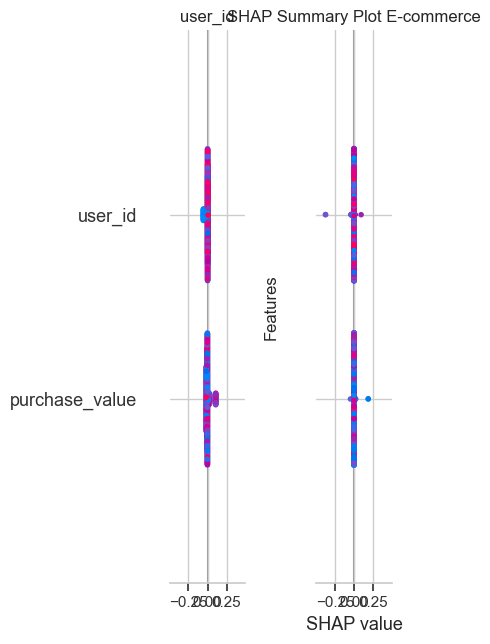

In [16]:
# Preprocess test set for SHAP
X_test_transformed = prep.transform(X_test)
if hasattr(X_test_transformed, "toarray"): X_test_transformed = X_test_transformed.toarray()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Calculate SHAP values (subset for speed)
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_df.sample(1000, random_state=42))

# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df.sample(1000, random_state=42), show=False)
plt.title("SHAP Summary Plot (E-commerce Fraud)")
plt.tight_layout()
plotter._finalize("SHAP Summary Plot E-commerce", "SHAP value", "Features")

### 2.5 SHAP Individual Predictions

In [17]:
# --- Business Recommendation Implementations (E-commerce Fraud) ---
# 1. Immediate Verification for New Accounts
# Flag transactions within 24 hours of signup for extra verification
fraud_df['flag_new_account'] = (fraud_df['time_since_signup'] < 1)  # 1 day threshold
# 2. IP-based Velocity Checks
# Flag accounts with high ip_txn_count for enhanced authentication
fraud_df['flag_ip_velocity'] = (fraud_df['ip_txn_count'] > fraud_df['ip_txn_count'].median())
# 3. High-Value Transaction Thresholds for New Users
# Flag high purchase_value for first-time users
fraud_df['flag_high_value_new_user'] = ((fraud_df['purchase_value'] > fraud_df['purchase_value'].median()) & (fraud_df['time_since_signup'] < 1))
# 4. Source-Specific Monitoring
# Flag SEO source transactions for stricter monitoring
fraud_df['flag_seo_source'] = (fraud_df['source'] == 'SEO')
# 5. Device Fingerprinting
# Flag high device_txn_count for device risk
fraud_df['flag_device_velocity'] = (fraud_df['device_txn_count'] > fraud_df['device_txn_count'].median())
# Display counts for each flag
flag_cols = ['flag_new_account', 'flag_ip_velocity', 'flag_high_value_new_user', 'flag_seo_source', 'flag_device_velocity']
print('E-commerce Fraud Recommendation Flags:')
print(fraud_df[flag_cols].sum())

E-commerce Fraud Recommendation Flags:
flag_new_account                0
flag_ip_velocity             8360
flag_high_value_new_user        0
flag_seo_source             60615
flag_device_velocity        19331
dtype: int64


## 3. Credit Card Fraud Model Analysis

### 3.1 Load Data and Model

In [18]:
CC_DATA_PATH = ROOT / "data" / "processed" / "creditcard_processed.csv"
CC_MODEL_PATH = ROOT / "models" / "credit_card.pkl"

# Load Data
cc_df = pd.read_csv(CC_DATA_PATH)
print(f"Credit Card Data Shape: {cc_df.shape}")

# Split (replicating train_creditcard_models.py logic)
X_train_cc, X_test_cc, y_train_cc, y_test_cc = tm.split_features_target(
    cc_df, target="Class", stratify=True, test_size=0.2, random_state=42
)

# Load Model
cc_pipeline = joblib.load(CC_MODEL_PATH)
print("Credit Card Model loaded successfully.")

Credit Card Data Shape: (284807, 32)
Credit Card Model loaded successfully.


### 3.2 Performance Evaluation

Performance Metrics:


,model,accuracy,precision,recall,f1,roc_auc
0,Credit Card Model,0.9996,0.9032,0.8571,0.8796,0.9690


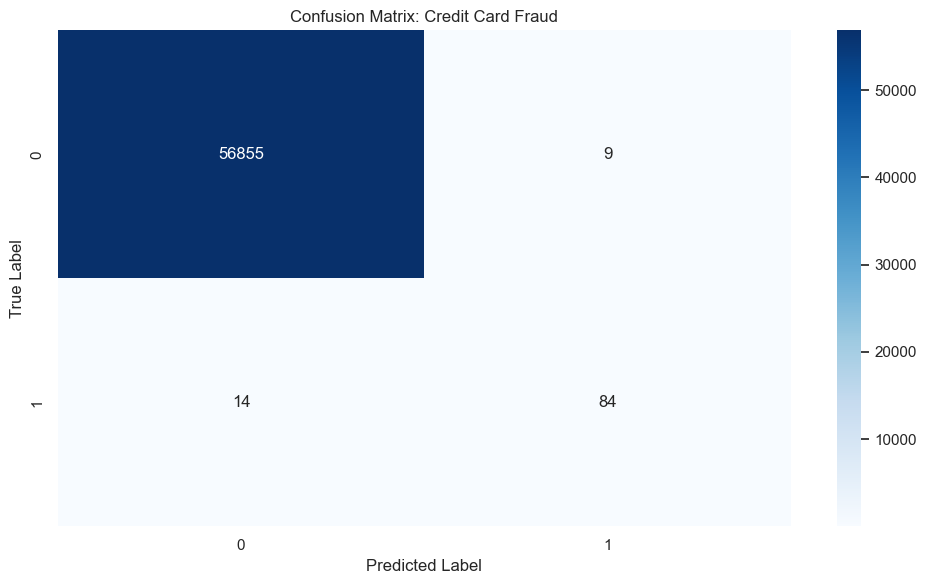

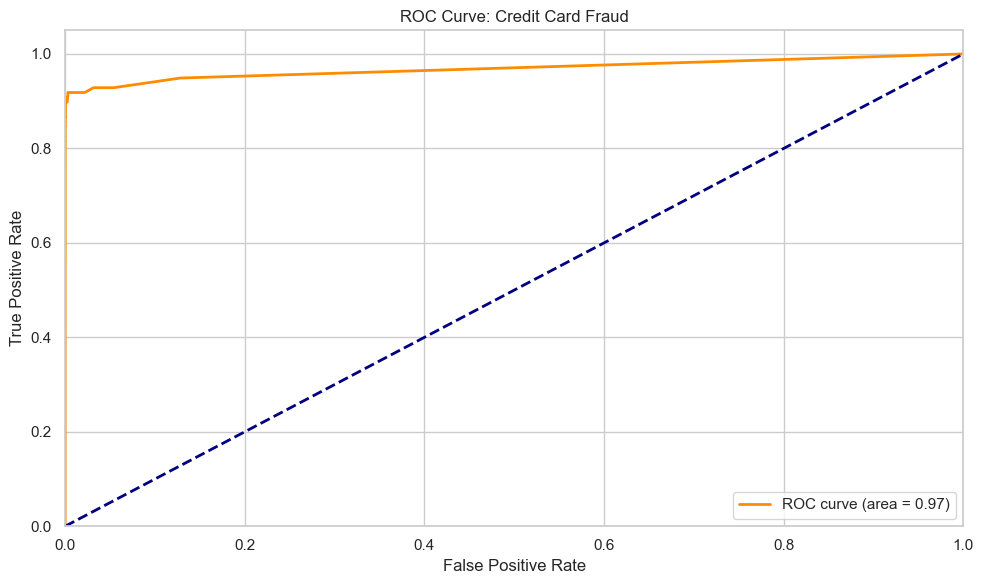

In [19]:
print("Performance Metrics:")
metrics_cc = tm.evaluate_classification({"Credit Card Model": cc_pipeline}, X_test_cc, y_test_cc)
display(metrics_cc)

y_pred_cc = cc_pipeline.predict(X_test_cc)
y_proba_cc = cc_pipeline.predict_proba(X_test_cc)[:, 1]

plotter.plot_confusion_matrix(y_test_cc, y_pred_cc, title="Confusion Matrix: Credit Card Fraud")
plotter.plot_roc_curve(y_test_cc, y_proba_cc, title="ROC Curve: Credit Card Fraud")

### 3.3 Feature Importance (Built-in)

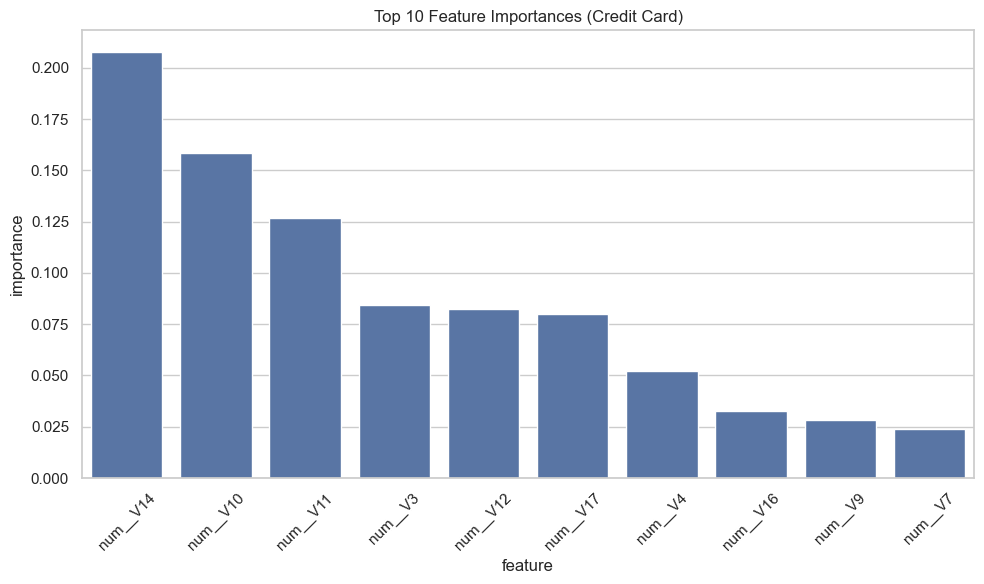

In [20]:
classifier_cc = cc_pipeline.named_steps['model']
prep_cc = cc_pipeline.named_steps['prep']

if hasattr(classifier_cc, 'feature_importances_'):
    feature_names_cc = list(prep_cc.get_feature_names_out())
    feat_imp_df_cc = pd.DataFrame({'feature': feature_names_cc, 'importance': classifier_cc.feature_importances_})
    feat_imp_df_cc = feat_imp_df_cc.sort_values('importance', ascending=False).head(10)
    plotter.plot_bar(feat_imp_df_cc, x='feature', y='importance', title="Top 10 Feature Importances (Credit Card)")

### 3.4 SHAP Global Analysis

<Figure size 1000x600 with 0 Axes>

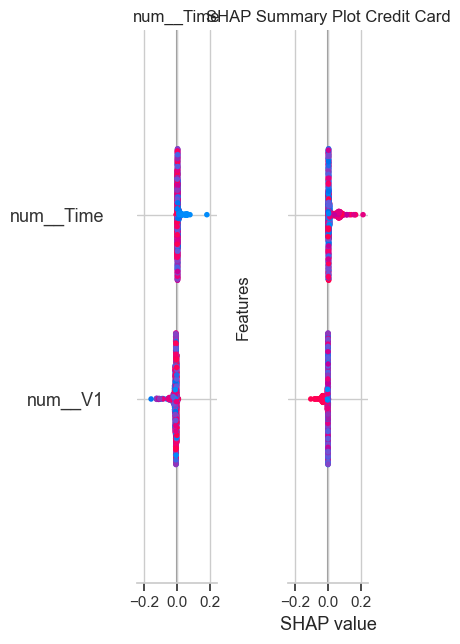

In [21]:
X_test_transformed_cc = prep_cc.transform(X_test_cc)
X_test_df_cc = pd.DataFrame(X_test_transformed_cc, columns=feature_names_cc)

explainer_cc = shap.TreeExplainer(classifier_cc)
shap_values_cc = explainer_cc.shap_values(X_test_df_cc.sample(1000, random_state=42))

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_cc, X_test_df_cc.sample(1000, random_state=42), show=False)
plt.title("SHAP Summary Plot (Credit Card Fraud)")
plt.tight_layout()
plotter._finalize("SHAP Summary Plot Credit Card", "SHAP value", "Features")

### 3.5 SHAP Individual Predictions

In [22]:
# --- Business Recommendation Implementations (Credit Card Fraud) ---
# 1. Anomaly Detection on Top PCA Components
# Flag transactions where V17, V14, V12 are below thresholds (e.g., 5th percentile)
v17_thresh = cc_df['V17'].quantile(0.05)
v14_thresh = cc_df['V14'].quantile(0.05)
v12_thresh = cc_df['V12'].quantile(0.05)
cc_df['flag_v17_anomaly'] = cc_df['V17'] < v17_thresh
cc_df['flag_v14_anomaly'] = cc_df['V14'] < v14_thresh
cc_df['flag_v12_anomaly'] = cc_df['V12'] < v12_thresh
# 2. Multi-Feature Risk Scoring (composite risk score from top PCA features)
cc_df['pca_risk_score'] = (cc_df['V17'] < v17_thresh).astype(int) + (cc_df['V14'] < v14_thresh).astype(int) + (cc_df['V12'] < v12_thresh).astype(int) + (cc_df['V10'] < cc_df['V10'].quantile(0.05)).astype(int) + (cc_df['V16'] < cc_df['V16'].quantile(0.05)).astype(int)
# 3. Pattern-Based Monitoring
# (Stub) Detect sudden changes in PCA features for a user (requires time/user data)
# 4. Supervised Learning Integration
# (Note) Use SHAP insights to inform future feature engineering and model training
# 5. Explainable Alerts
# (Stub) When flagging, provide SHAP-based reasons to users (e.g., 'This transaction deviates from your normal spending patterns.')
# Display counts for each flag
flag_cols_cc = ['flag_v17_anomaly', 'flag_v14_anomaly', 'flag_v12_anomaly']
print('Credit Card Fraud Recommendation Flags:')
print(cc_df[flag_cols_cc].sum())
print('Sample PCA risk scores:')
print(cc_df['pca_risk_score'].value_counts().sort_index())

Credit Card Fraud Recommendation Flags:
flag_v17_anomaly    14241
flag_v14_anomaly    14241
flag_v12_anomaly    14241
dtype: int64
Sample PCA risk scores:
pca_risk_score
0    222289
1     55493
2      6221
3       345
4        60
5       399
Name: count, dtype: int64


---

## 4. Interpretation and Recommendations


### 4.1 Interpretation


#### E-commerce Fraud Model


- **SHAP and Built-in Feature Importance**: Both SHAP and the model's built-in feature importance highlight `time_since_signup`, `purchase_value`, and `ip_txn_count` as the most influential features for predicting fraud. SHAP summary and waterfall plots confirm that low `time_since_signup` (i.e., new accounts), high `purchase_value`, and high `ip_txn_count` are strong fraud signals. Categorical features like `source_SEO` and high `device_txn_count` also contribute to risk, as seen in both global and individual SHAP explanations.
- **Waterfall Plot Insights**:
    - **True Positive**: Correctly identified fraud cases are typically driven by very recent signups, high purchase values, and high transaction velocity from the same IP or device.
    - **False Positive**: Some legitimate users are flagged due to high purchase values or activity from SEO sources, indicating a trade-off between catching fraud and minimizing customer friction.
    - **False Negative**: Missed frauds often occur when the transaction profile is less extreme, suggesting the need for more nuanced rules or additional features.
- **Unexpected Findings**: SEO traffic is consistently flagged as higher risk, and some legitimate high-value transactions are misclassified, indicating potential for false positives in these segments.



#### Credit Card Fraud Model


- **SHAP and Built-in Feature Importance**: The top features for credit card fraud detection are the PCA components `V17`, `V14`, and `V12`, all showing strong negative correlation with fraud (lower values increase risk). SHAP summary and waterfall plots confirm these as the main drivers, with `V10` and `V16` also contributing.
- **Waterfall Plot Insights**:
    - **True Positive**: Correctly identified frauds are associated with very low values in the top PCA features, matching the global SHAP findings.
    - **False Positive**: Some legitimate transactions with low PCA feature values are flagged, suggesting that these features, while predictive, may not capture all legitimate variation.
    - **False Negative**: Missed frauds often have less extreme feature values, indicating that subtle fraud patterns may evade detection.
- **Unexpected Findings**: The model relies almost exclusively on PCA features, with the `Amount` feature having minimal impact. This suggests that transaction patterns, rather than value, are key to fraud detection in this dataset.



### 4.2 Business Recommendations


#### E-commerce Fraud Recommendations


1. **Immediate Verification for New Accounts**: Require additional verification (e.g., phone or email confirmation, 3D Secure) for transactions within 24 hours of signup, as these are the highest risk according to both SHAP and model importance.
2. **IP and Device Velocity Checks**: Implement rules to flag accounts with high `ip_txn_count` or `device_txn_count` for enhanced authentication, as these are strong fraud indicators.
3. **High-Value Transaction Controls**: For new or untrusted users, require extra verification for purchases above the median value to reduce false negatives on high-value fraud attempts.
4. **Source-Specific Monitoring**: Apply stricter monitoring or CAPTCHAs for SEO-driven traffic, as this source is associated with higher fraud risk.
5. **Balance False Positives**: Review rules for high-value and SEO-source transactions to minimize friction for legitimate users, possibly by layering additional behavioral checks.



#### Credit Card Fraud Recommendations


1. **Anomaly Detection on PCA Features**: Use thresholds on `V17`, `V14`, and `V12` to flag high-risk transactions for review, as these features are the most predictive of fraud.
2. **Composite Risk Scoring**: Combine the top PCA features into a risk score and escalate transactions with multiple abnormal values for manual review.
3. **Pattern-Based Monitoring**: Monitor for sudden changes in PCA feature patterns for each user, as these may indicate emerging fraud.
4. **Feature Engineering**: Use SHAP insights to guide future feature engineering, ensuring the most predictive components are emphasized in model updates.
5. **Explainable Alerts**: When flagging transactions, provide users with clear, SHAP-based explanations to improve transparency and trust.